# Multiplayer Top Trumps: Optimierung

## Multi-Objective Optimization für 3+ Spieler

Dieses Notebook führt die NSGA-II Optimierung für Multiplayer-Szenarien durch.

**Voraussetzung:** `01_setup.ipynb` muss zuerst ausgeführt werden!

## 1. Setup

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))
import json

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.core.callback import Callback
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16

In [3]:
from simulation import (
    TopTrumpsMultiplayerSimulation,
    TopTrumpsMultiplayerBalancing,
    evaluate_multiplayer_deck_detailed
)

In [4]:
SEED = 42

def set_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)

set_seeds(SEED)

In [5]:
RESULTS_DIR = Path('../results/multiplayer')
PLOTS_DIR = Path('../plots/multiplayer')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

config_path = RESULTS_DIR / 'config.json'
with open(config_path, 'r') as f:
    CONFIG = json.load(f)

print('Geladene Konfiguration:')
print(json.dumps(CONFIG, indent=2))

Geladene Konfiguration:
{
  "seed": 42,
  "K": 24,
  "L": 4,
  "n_var": 96,
  "xl": 1.0,
  "xu": 10.0,
  "player_strategies": [
    "p4",
    "p0",
    "p0"
  ],
  "num_players": 3,
  "num_experts": 1,
  "num_beginners": 2,
  "cards_per_player": 8,
  "R_eval_fast": 1000,
  "R_eval_final": 1500,
  "exploration_stats": {
    "focus_expert_win_rate_range": [
      0.31,
      0.6
    ],
    "trick_changes_range": [
      1.89,
      3.13
    ],
    "tie_rate_range": [
      0.06,
      0.25
    ]
  }
}


In [6]:
K = CONFIG['K']
L = CONFIG['L']
XL = CONFIG['xl']
XU = CONFIG['xu']
PLAYER_STRATEGIES = CONFIG['player_strategies']
NUM_PLAYERS = CONFIG['num_players']

print(f'\nOptimierung für {NUM_PLAYERS} Spieler: {PLAYER_STRATEGIES}')


Optimierung für 3 Spieler: ['p4', 'p0', 'p0']


---

## 2. Optimierungs-Parameter

In [7]:
POP_SIZE = 80
N_GEN = 150
R_EVAL_FAST = 1000   # Simulations during optimization
R_EVAL_FINAL = 1500  # Simulations for validation

print('=== Optimierungs-Parameter ===')
print(f'Population Size:  {POP_SIZE}')
print(f'Generationen:     {N_GEN}')
print(f'R (Fast):         {R_EVAL_FAST}')
print(f'R (Final):        {R_EVAL_FINAL}')
print(f'Total Evaluations: ~{POP_SIZE * N_GEN:,}')

=== Optimierungs-Parameter ===
Population Size:  80
Generationen:     150
R (Fast):         1000
R (Final):        1500
Total Evaluations: ~12,000


---

## 3. Konvergenz-Callback

Wir tracken den Hypervolume über die Generationen, um die Konvergenz zu analysieren.

In [8]:
class ConvergenceCallback(Callback):
    """
    Callback zur Aufzeichnung der Konvergenz während der Optimierung.
    Trackt Hypervolume, Anzahl Pareto-Lösungen und beste Werte pro Generation.
    """
    
    def __init__(self, ref_point=np.array([0.0, 0.0])):
        super().__init__()
        self.ref_point = ref_point
        self.hv_indicator = HV(ref_point=ref_point)
        self.history = {
            'generation': [],
            'hypervolume': [],
            'n_pareto': [],
            'best_f1': [],
            'best_f2': [],
            'time': []
        }
        self.start_time = None
    
    def notify(self, algorithm):
        if self.start_time is None:
            self.start_time = time.time()
        
        F = algorithm.pop.get('F')
        
        hv = self.hv_indicator(F)
        
        self.history['generation'].append(algorithm.n_gen)
        self.history['hypervolume'].append(hv)
        self.history['n_pareto'].append(len(F))
        self.history['best_f1'].append(-F[:, 0].min())
        self.history['best_f2'].append(-F[:, 1].min())
        self.history['time'].append(time.time() - self.start_time)

print('Konvergenz-Callback definiert.')

Konvergenz-Callback definiert.


---

## 4. Simulation & Problem erstellen

In [9]:
sim = TopTrumpsMultiplayerSimulation(
    num_cards=K,
    num_categories=L,
    player_strategies=PLAYER_STRATEGIES
)

problem = TopTrumpsMultiplayerBalancing(
    sim_instance=sim,
    n_simulations=R_EVAL_FAST,
    xl=XL,
    xu=XU
)

print(f'Problem erstellt:')
print(f'  n_var: {problem.n_var}')
print(f'  n_obj: {problem.n_obj}')
print(f'  Expert-Spieler: {problem.expert_indices}')

Problem erstellt:
  n_var: 96
  n_obj: 2
  Expert-Spieler: [0]


---

## 5. NSGA-II Optimierung mit Konvergenz-Tracking

In [10]:
algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination('n_gen', N_GEN)
convergence_callback = ConvergenceCallback()

print('Starte Optimierung mit Konvergenz-Tracking...')
print(f'Erwartete Laufzeit: ~{POP_SIZE * N_GEN * R_EVAL_FAST / 50000:.1f} Minuten')
print()

Starte Optimierung mit Konvergenz-Tracking...
Erwartete Laufzeit: ~240.0 Minuten



In [11]:
set_seeds(SEED)

start_time = time.time()
res = minimize(
    problem,
    algorithm,
    termination,
    seed=SEED,
    callback=convergence_callback,
    verbose=True
)
optimization_time = time.time() - start_time

print(f'\n=== Optimierung abgeschlossen ===')
print(f'Laufzeit: {optimization_time:.1f}s ({optimization_time/60:.1f} min)')
print(f'Gefundene Lösungen: {len(res.F)}')

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       80 |      3 |             - |             -


     2 |      160 |      1 |  0.1530000000 |         ideal


     3 |      240 |      1 |  0.000000E+00 |             f


     4 |      320 |      2 |  1.0000000000 |         ideal


     5 |      400 |      2 |  0.000000E+00 |             f


...

   146 |    11680 |     29 |  0.0031604357 |             f


   147 |    11760 |     29 |  0.000000E+00 |             f


   148 |    11840 |     29 |  0.000000E+00 |             f


   149 |    11920 |     29 |  0.000000E+00 |             f


   150 |    12000 |     29 |  0.000000E+00 |             f

=== Optimierung abgeschlossen ===
Laufzeit: 264.8s (4.4 min)
Gefundene Lösungen: 29


---

## 6. Konvergenz-Analyse

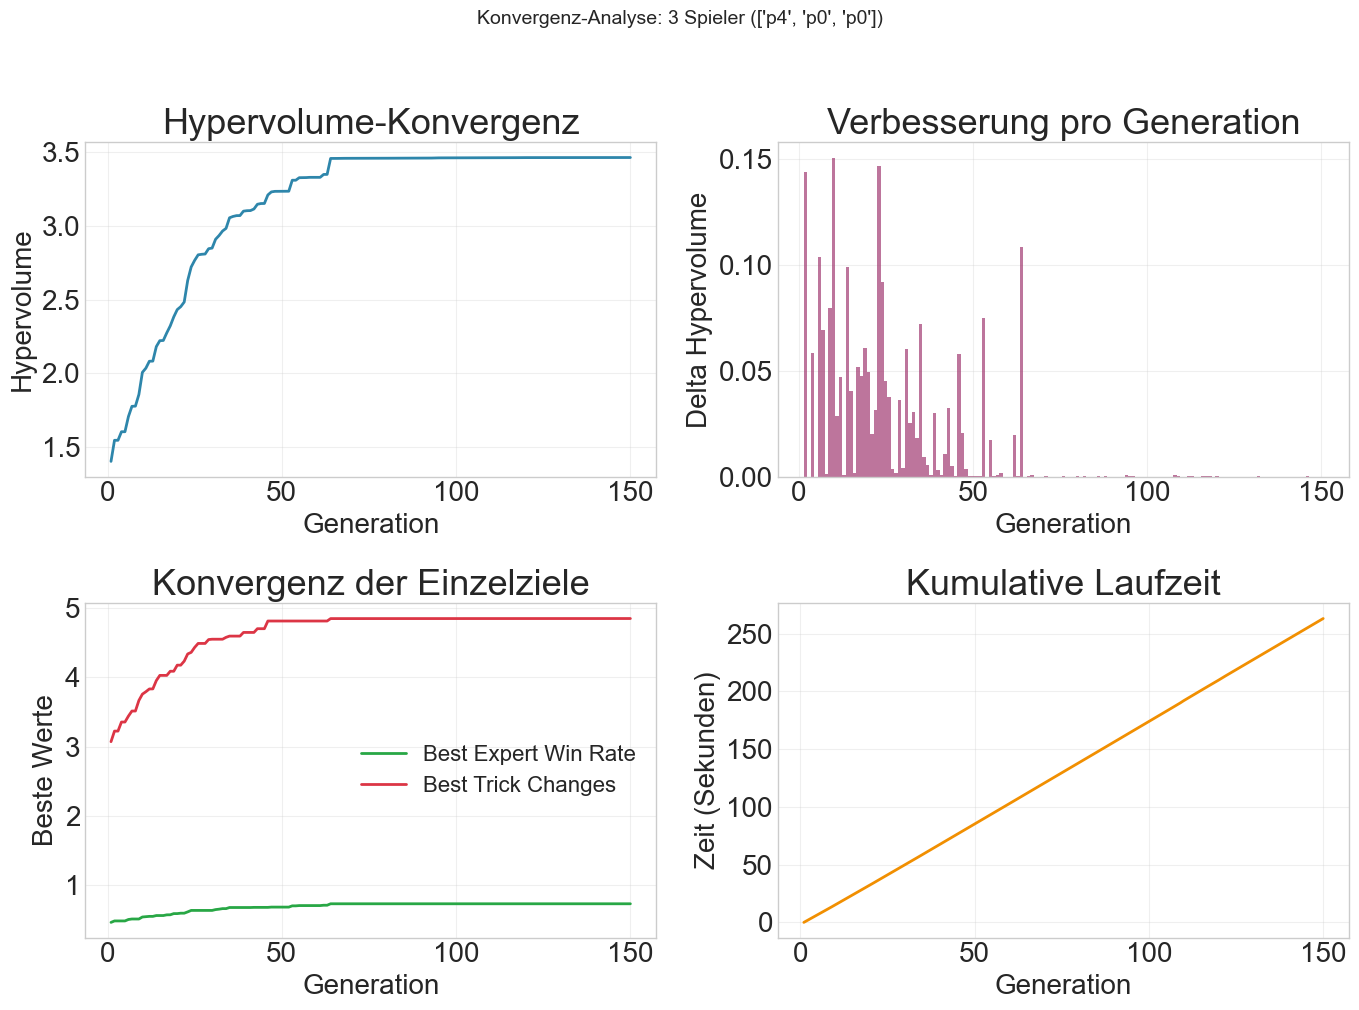


-> Plot gespeichert: plots/multiplayer/convergence_analysis.png


In [12]:
convergence_df = pd.DataFrame(convergence_callback.history)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hypervolume über Generationen
ax1 = axes[0, 0]
ax1.plot(convergence_df['generation'], convergence_df['hypervolume'], 
         color='#2E86AB', linewidth=2)
ax1.set_xlabel('Generation')
ax1.set_ylabel('Hypervolume')
ax1.set_title('Hypervolume-Konvergenz')
ax1.grid(True, alpha=0.3)

# Verbesserungsrate (Delta HV)
ax2 = axes[0, 1]
hv_diff = np.diff(convergence_df['hypervolume'])
ax2.bar(convergence_df['generation'][1:], hv_diff, color='#A23B72', alpha=0.7, width=1)
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Generation')
ax2.set_ylabel('Delta Hypervolume')
ax2.set_title('Verbesserung pro Generation')
ax2.grid(True, alpha=0.3)

# Beste Werte pro Objective
ax3 = axes[1, 0]
ax3.plot(convergence_df['generation'], convergence_df['best_f1'], 
         label='Best Expert Win Rate', color='#28A745', linewidth=2)
ax3.plot(convergence_df['generation'], convergence_df['best_f2'], 
         label='Best Trick Changes', color='#DC3545', linewidth=2)
ax3.set_xlabel('Generation')
ax3.set_ylabel('Beste Werte')
ax3.set_title('Konvergenz der Einzelziele')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Kumulative Zeit
ax4 = axes[1, 1]
ax4.plot(convergence_df['generation'], convergence_df['time'], 
         color='#F18F01', linewidth=2)
ax4.set_xlabel('Generation')
ax4.set_ylabel('Zeit (Sekunden)')
ax4.set_title('Kumulative Laufzeit')
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Konvergenz-Analyse: {NUM_PLAYERS} Spieler ({PLAYER_STRATEGIES})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'convergence_analysis.svg', format='svg', bbox_inches='tight')
plt.show()

print(f'\n-> Plot gespeichert: {PLOTS_DIR / "convergence_analysis.png"}')

In [13]:
# Konvergenz-Statistiken
final_hv = convergence_df['hypervolume'].iloc[-1]
hv_at_50 = convergence_df['hypervolume'].iloc[min(49, len(convergence_df)-1)]
hv_at_100 = convergence_df['hypervolume'].iloc[min(99, len(convergence_df)-1)]

# Wann wurde 90% des finalen HV erreicht?
target_hv = 0.9 * final_hv
gen_90_pct = convergence_df[convergence_df['hypervolume'] >= target_hv]['generation'].iloc[0]

# Wann wurde 95% erreicht?
target_hv_95 = 0.95 * final_hv
gen_95_pct = convergence_df[convergence_df['hypervolume'] >= target_hv_95]['generation'].iloc[0]

print('=== Konvergenz-Statistiken ===')
print(f'Finaler Hypervolume:       {final_hv:.4f}')
print(f'HV nach 50 Generationen:   {hv_at_50:.4f} ({hv_at_50/final_hv*100:.1f}% des Finalen)')
print(f'HV nach 100 Generationen:  {hv_at_100:.4f} ({hv_at_100/final_hv*100:.1f}% des Finalen)')
print(f'\n90% des finalen HV erreicht in Generation: {gen_90_pct}')
print(f'95% des finalen HV erreicht in Generation: {gen_95_pct}')
print(f'\nDurchschnittliche Zeit pro Generation: {optimization_time / N_GEN:.2f}s')

=== Konvergenz-Statistiken ===
Finaler Hypervolume:       3.4658
HV nach 50 Generationen:   3.2362 (93.4% des Finalen)
HV nach 100 Generationen:  3.4634 (99.9% des Finalen)

90% des finalen HV erreicht in Generation: 43
95% des finalen HV erreicht in Generation: 53

Durchschnittliche Zeit pro Generation: 1.77s


---

## 7. Pareto-Front visualisieren

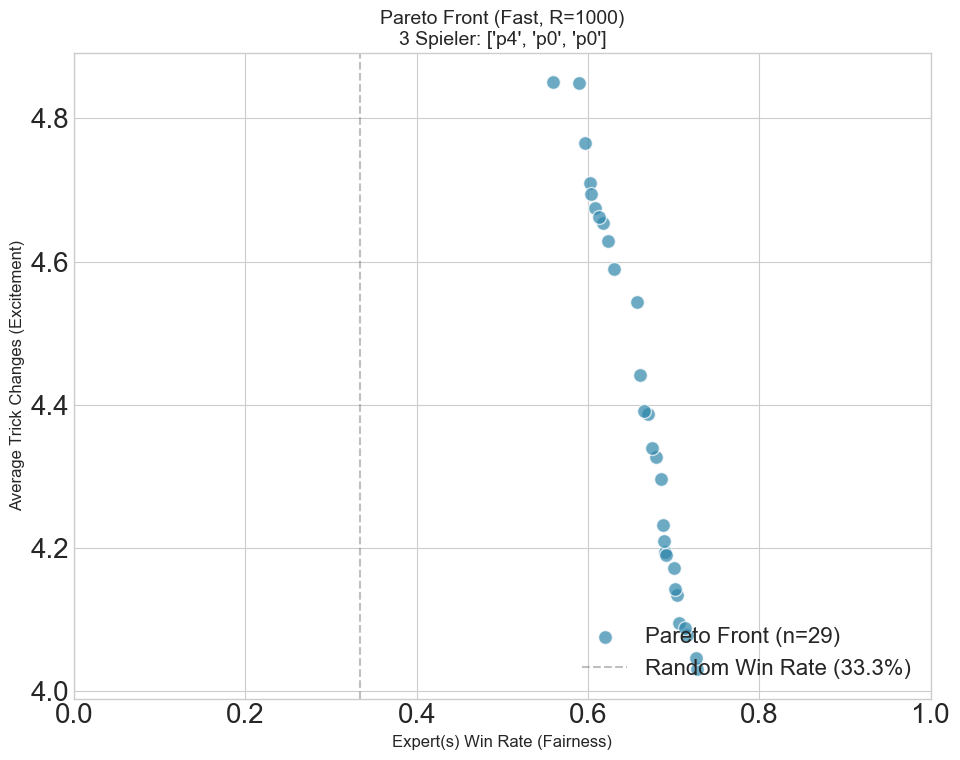

In [14]:
F_fast = res.F

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    -F_fast[:, 0],
    -F_fast[:, 1],
    c='#2E86AB',
    s=100,
    alpha=0.7,
    edgecolors='white',
    linewidth=1,
    label=f'Pareto Front (n={len(F_fast)})'
)

expected_random = 1 / NUM_PLAYERS
ax.axvline(expected_random, color='gray', linestyle='--', alpha=0.5, 
           label=f'Random Win Rate ({expected_random:.1%})')

ax.set_xlabel('Expert(s) Win Rate (Fairness)', fontsize=12)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax.set_title(f'Pareto Front (Fast, R={R_EVAL_FAST})\n'
             f'{NUM_PLAYERS} Spieler: {PLAYER_STRATEGIES}', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_front_fast.svg', format='svg', bbox_inches='tight')
plt.show()

---

## 8. Validierung mit R=1000

In [15]:
print(f'Validiere {len(res.X)} Lösungen mit R={R_EVAL_FINAL}...')

validated_results = []
for i, x in enumerate(res.X):
    metrics = evaluate_multiplayer_deck_detailed(sim, x, R=R_EVAL_FINAL)
    validated_results.append({
        'idx': i,
        'focus_expert_win_rate': metrics['focus_expert_win_rate'],
        'any_expert_win_rate': metrics['any_expert_win_rate'],
        'trick_changes': metrics['trick_changes'],
        'tie_rate': metrics['tie_rate'],
        'focus_expert_win_rate_ci': metrics['focus_expert_win_rate_ci'],
        'trick_changes_ci': metrics['trick_changes_ci']
    })
    if (i + 1) % 10 == 0:
        print(f'  {i + 1}/{len(res.X)} validiert')

validated_df = pd.DataFrame(validated_results)

# Non-Dominated Sorting: Remove dominated solutions after validation
F_validated = np.column_stack([
    -validated_df['focus_expert_win_rate'].values,
    -validated_df['trick_changes'].values
])
nds = NonDominatedSorting()
fronts = nds.do(F_validated)
non_dominated_idx = fronts[0]

n_before = len(validated_df)
validated_df = validated_df.iloc[non_dominated_idx].reset_index(drop=True)
# Auch die Deck-Daten (res.X, res.F) filtern für spätere Verwendung
res_X_filtered = res.X[non_dominated_idx]
res_F_filtered = res.F[non_dominated_idx]

print('\nValidierung abgeschlossen!')
print(f'Non-Dominated Sorting: {n_before} -> {len(validated_df)} Lösungen ({n_before - len(validated_df)} dominierte entfernt)')

Validiere 29 Lösungen mit R=1500...


  10/29 validiert


  20/29 validiert



Validierung abgeschlossen!
Non-Dominated Sorting: 29 -> 13 Lösungen (16 dominierte entfernt)


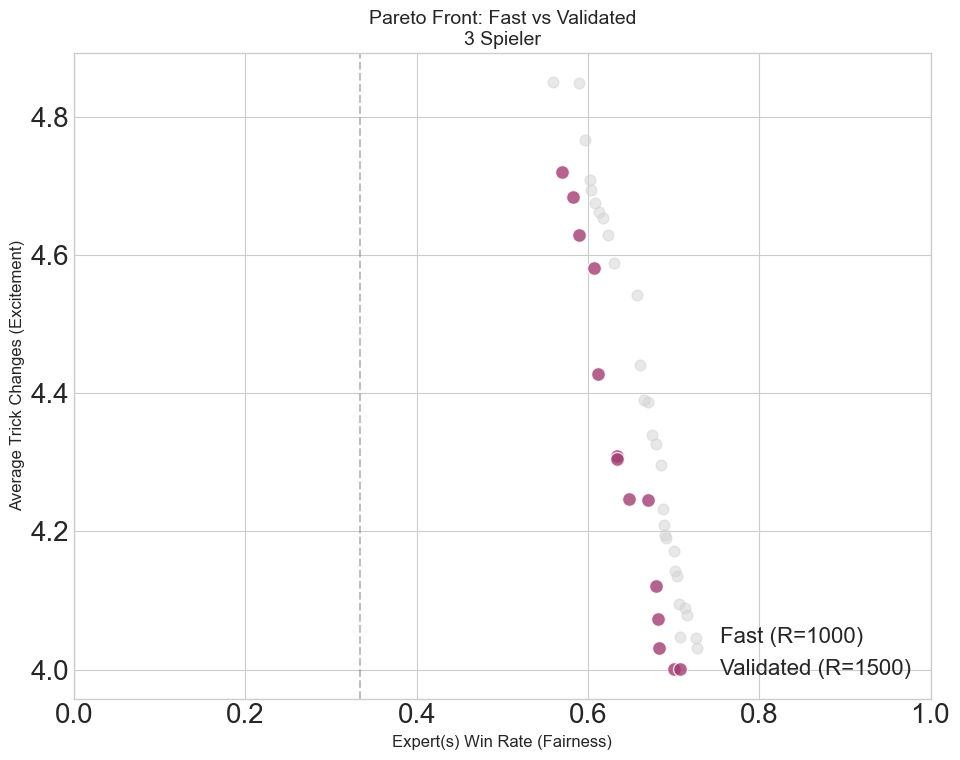

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(-F_fast[:, 0], -F_fast[:, 1], c='lightgray', s=60, alpha=0.5, label=f'Fast (R={R_EVAL_FAST})')
ax.scatter(validated_df['focus_expert_win_rate'], validated_df['trick_changes'],
           c='#A23B72', s=100, alpha=0.8, edgecolors='white', linewidth=1,
           label=f'Validated (R={R_EVAL_FINAL})')

ax.axvline(1/NUM_PLAYERS, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Expert(s) Win Rate (Fairness)', fontsize=12)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax.set_title(f'Pareto Front: Fast vs Validated\n{NUM_PLAYERS} Spieler', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_front_validated.svg', format='svg', bbox_inches='tight')
plt.show()

---

## 9. Quality Indicator: Hypervolume

In [17]:
F_validated = np.column_stack([
    -validated_df['focus_expert_win_rate'].values,
    -validated_df['trick_changes'].values
])

ref_point = np.array([0.0, 0.0])
hv_indicator = HV(ref_point=ref_point)

hv_fast = hv_indicator(F_fast)
hv_validated = hv_indicator(F_validated)

print('=== Hypervolume ===')
print(f'Fast (R={R_EVAL_FAST}):      {hv_fast:.4f}')
print(f'Validated (R={R_EVAL_FINAL}): {hv_validated:.4f}')
print(f'Optimistischer Bias: {(hv_fast - hv_validated) / hv_fast * 100:.1f}%')

=== Hypervolume ===
Fast (R=1000):      3.4658
Validated (R=1500): 3.2527
Optimistischer Bias: 6.1%


---

## 10. Repräsentative Decks auswählen

In [18]:
idx_fairness = validated_df['focus_expert_win_rate'].idxmax()
idx_excitement = validated_df['trick_changes'].idxmax()

norm_wr = (validated_df['focus_expert_win_rate'] - validated_df['focus_expert_win_rate'].min()) / \
          (validated_df['focus_expert_win_rate'].max() - validated_df['focus_expert_win_rate'].min() + 1e-9)
norm_tc = (validated_df['trick_changes'] - validated_df['trick_changes'].min()) / \
          (validated_df['trick_changes'].max() - validated_df['trick_changes'].min() + 1e-9)
idx_knee = (norm_wr + norm_tc).idxmax()

selected_indices = {'fairness_max': idx_fairness, 'excitement_max': idx_excitement, 'knee_point': idx_knee}

print('=== Repräsentative Decks ===')
for name, idx in selected_indices.items():
    row = validated_df.iloc[idx]
    print(f'\n{name}:')
    print(f'  Focus Expert Win Rate: {row["focus_expert_win_rate"]:.1%}')
    print(f'  Trick Changes:   {row["trick_changes"]:.2f}')
    print(f'  Tie Rate:        {row["tie_rate"]:.1%}')

=== Repräsentative Decks ===

fairness_max:
  Focus Expert Win Rate: 70.0%
  Trick Changes:   4.00
  Tie Rate:        18.3%

excitement_max:
  Focus Expert Win Rate: 57.0%
  Trick Changes:   4.72
  Tie Rate:        23.1%

knee_point:
  Focus Expert Win Rate: 67.0%
  Trick Changes:   4.25
  Tie Rate:        20.7%


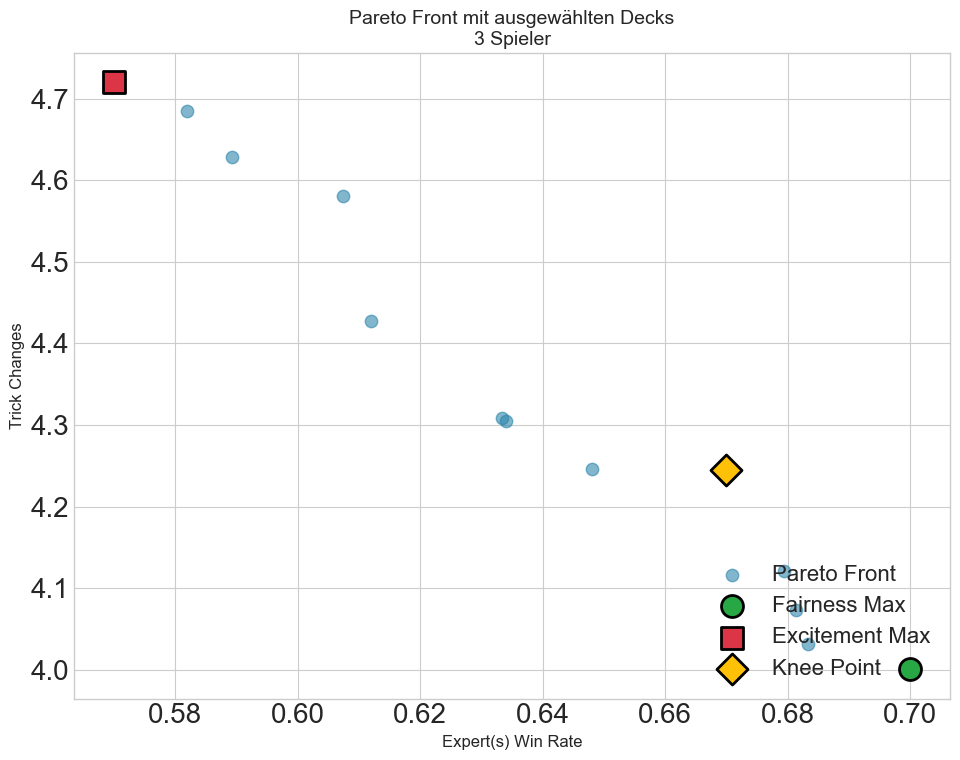

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(validated_df['focus_expert_win_rate'], validated_df['trick_changes'],
           c='#2E86AB', s=80, alpha=0.6, label='Pareto Front')

markers = {'fairness_max': ('o', '#28A745', 'Fairness Max'),
           'excitement_max': ('s', '#DC3545', 'Excitement Max'),
           'knee_point': ('D', '#FFC107', 'Knee Point')}

for name, idx in selected_indices.items():
    row = validated_df.iloc[idx]
    marker, color, label = markers[name]
    ax.scatter(row['focus_expert_win_rate'], row['trick_changes'],
               marker=marker, c=color, s=250, edgecolors='black', linewidth=2, label=label, zorder=10)

ax.set_xlabel('Expert(s) Win Rate', fontsize=12)
ax.set_ylabel('Trick Changes', fontsize=12)
ax.set_title(f'Pareto Front mit ausgewählten Decks\n{NUM_PLAYERS} Spieler', fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_front_selected.svg', format='svg', bbox_inches='tight')
plt.show()

---

## 11. Ergebnisse speichern

In [20]:
np.save(RESULTS_DIR / 'pareto_front_X.npy', res_X_filtered)
np.save(RESULTS_DIR / 'pareto_front_F.npy', res_F_filtered)
validated_df.to_csv(RESULTS_DIR / 'validated_front.csv', index=False)
convergence_df.to_csv(RESULTS_DIR / 'convergence_history.csv', index=False)

selected_decks = {}
for name, idx in selected_indices.items():
    selected_decks[name] = {
        'deck': res_X_filtered[idx].tolist(),
        'metrics': validated_df.iloc[idx].to_dict()
    }

with open(RESULTS_DIR / 'selected_decks.json', 'w') as f:
    json.dump(selected_decks, f, indent=2)

optimization_stats = {
    'pop_size': POP_SIZE,
    'n_gen': N_GEN,
    'R_eval_fast': R_EVAL_FAST,
    'R_eval_final': R_EVAL_FINAL,
    'optimization_time_s': optimization_time,
    'n_solutions': len(res_F_filtered),
    'hypervolume_fast': float(hv_fast),
    'hypervolume_validated': float(hv_validated),
    'player_strategies': PLAYER_STRATEGIES,
    'convergence': {
        'gen_90_pct': int(gen_90_pct),
        'gen_95_pct': int(gen_95_pct),
        'final_hv': float(final_hv)
    }
}

with open(RESULTS_DIR / 'optimization_results.json', 'w') as f:
    json.dump(optimization_stats, f, indent=2)

print('=== Alle Ergebnisse gespeichert ===')
for f in RESULTS_DIR.glob('*'):
    print(f'  {f.name}')

=== Alle Ergebnisse gespeichert ===
  optimization_results.json
  config.json
  selected_decks.json
  validated_front.csv
  pareto_front_F.npy
  pareto_front_X.npy
  convergence_history.csv


---

## 12. Zusammenfassung

In [21]:
print('\n' + '=' * 60)
print('MULTIPLAYER OPTIMIERUNG ABGESCHLOSSEN')
print('=' * 60)
print(f'\nKonfiguration:')
print(f'  Spieler:      {NUM_PLAYERS} ({PLAYER_STRATEGIES})')
print(f'  Karten:       {K}')
print(f'  Kategorien:   {L}')
print(f'\nErgebnisse:')
print(f'  Laufzeit:     {optimization_time:.1f}s')
print(f'  Lösungen:     {len(res_F_filtered)}')
print(f'  Hypervolume:  {hv_validated:.4f}')
print(f'\nKonvergenz:')
print(f'  90% HV in Gen: {gen_90_pct}')
print(f'  95% HV in Gen: {gen_95_pct}')
print(f'\nBest Metrics:')
print(f'  Max Focus Expert Win Rate: {validated_df["focus_expert_win_rate"].max():.1%}')
print(f'  Max Trick Changes:   {validated_df["trick_changes"].max():.2f}')
print('\n' + '=' * 60)


MULTIPLAYER OPTIMIERUNG ABGESCHLOSSEN

Konfiguration:
  Spieler:      3 (['p4', 'p0', 'p0'])
  Karten:       24
  Kategorien:   4

Ergebnisse:
  Laufzeit:     264.8s
  Lösungen:     13
  Hypervolume:  3.2527

Konvergenz:
  90% HV in Gen: 43
  95% HV in Gen: 53

Best Metrics:
  Max Focus Expert Win Rate: 70.0%
  Max Trick Changes:   4.72

